In [26]:
import numpy as np
import pandas as pd

In [27]:
import matplotlib.pyplot as plt     # plotting graphs

from sklearn.tree import DecisionTreeClassifier   # build a classification tree
from sklearn.tree import plot_tree               # visualize the decision tree

from sklearn.model_selection import train_test_split   # split into train/test
from sklearn.model_selection import cross_val_score    # cross-validation

from sklearn.metrics import ConfusionMatrixDisplay     # draw confusion matrix

In [28]:
df = pd.read_csv('processed.cleveland.data')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   63.0    302 non-null    float64
 1   1.0     302 non-null    float64
 2   1.0.1   302 non-null    float64
 3   145.0   302 non-null    float64
 4   233.0   302 non-null    float64
 5   1.0.2   302 non-null    float64
 6   2.0     302 non-null    float64
 7   150.0   302 non-null    float64
 8   0.0     302 non-null    float64
 9   2.3     302 non-null    float64
 10  3.0     302 non-null    float64
 11  0.0.1   302 non-null    object 
 12  6.0     302 non-null    object 
 13  0       302 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.2+ KB


In [29]:



df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','hd']



In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    float64
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    float64
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    float64
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    object 
 12  thal      302 non-null    object 
 13  hd        302 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.2+ KB


In [31]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
hd          0
dtype: int64

In [32]:
df['ca'].unique()


array(['3.0', '2.0', '0.0', '1.0', '?'], dtype=object)

In [33]:
df['thal'].unique()

array(['3.0', '7.0', '6.0', '?'], dtype=object)

In [34]:
df.loc[(df['ca']=='?')| (df['thal']=='?')]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
86,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
165,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
191,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
265,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
286,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
301,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [35]:
len(df.loc[(df['ca']=='?')| (df['thal']=='?')])

6

In [36]:
len(df)

302

In [37]:
df_no_missing = df.loc[(df['ca']!='?')& (df['thal']!='?')]
len(df_no_missing)

296

In [38]:
df_no_missing['ca'].unique()
df.isnull().sum()
df['sex'].unique()


array([1., 0.])

In [39]:
x = df_no_missing.drop('hd',axis=1).copy()
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0


In [40]:
y = df_no_missing['hd'].copy()
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


In [43]:
dt = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=our_main_alpha  # use the alpha you already selected
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt)
])


NameError: name 'our_main_alpha' is not defined

In [ ]:
X = df_no_missing.drop("hd", axis=1)
y = df_no_missing["hd"].copy()

y[y > 0] = 1



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
import joblib
joblib.dump(pipeline, "models/heart_risk_pipeline.pkl")


['models/heart_risk_pipeline.pkl']

In [ ]:
path = clf_dt.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]
clf_dts = []
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf_dt.fit(x_train, y_train)
    clf_dts.append(clf_dt)


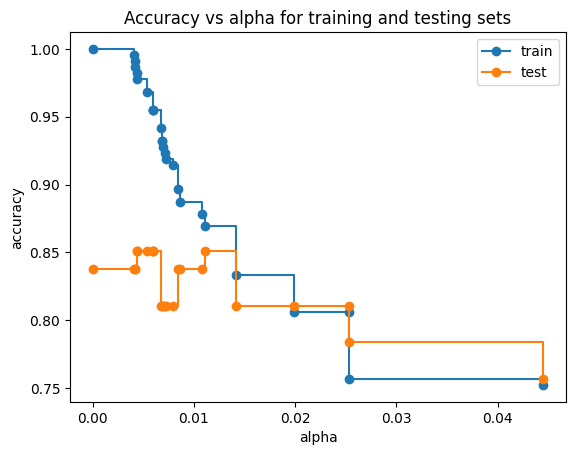

In [ ]:
# Get the accuracy scores for each pruned tree
train_scores = [clf_dt.score(x_train, y_train) for clf_dt in clf_dts]
test_scores  = [clf_dt.score(x_test,  y_test)  for clf_dt in clf_dts]

# Plotting
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")

ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores,  marker='o', label="test",  drawstyle="steps-post")

ax.legend()
plt.show()


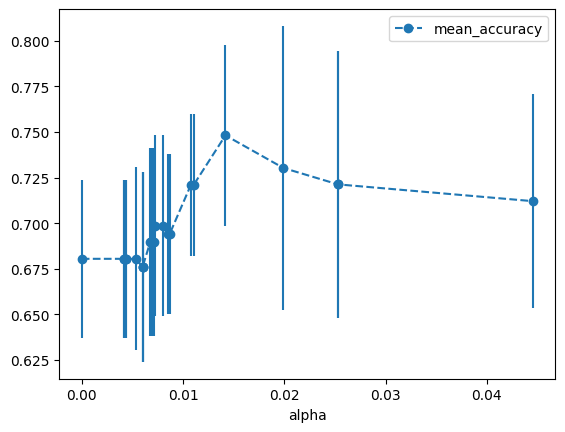

In [ ]:
alpha_loop_values = []


for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf_dt, x_train, y_train, cv=5)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])


alpha_results = pd.DataFrame(alpha_loop_values,
                             columns=['alpha', 'mean_accuracy', 'std'])

alpha_results.plot(x='alpha',
                   y='mean_accuracy',
                   yerr='std',
                   marker='o',
                   linestyle='--')
plt.show()


In [ ]:

alpha_results[(alpha_results['alpha'] > 0.012) &
              (alpha_results['alpha'] < 0.015)]


,alpha,mean_accuracy,std
21,0.01419,0.748182,0.049741


In [ ]:
alpha_results[(alpha_results['alpha'] > 0.012) &
              (alpha_results['alpha'] < 0.015)]['alpha']


21    0.01419
Name: alpha, dtype: float64

In [ ]:
our_main_alpha = alpha_results[(alpha_results['alpha'] > 0.012) &
              (alpha_results['alpha'] < 0.015)]['alpha']

In [ ]:
our_main_alpha = float(our_main_alpha)

C:\Users\aryan\AppData\Local\Temp\ipykernel_29108\1919268785.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  our_main_alpha = float(our_main_alpha)


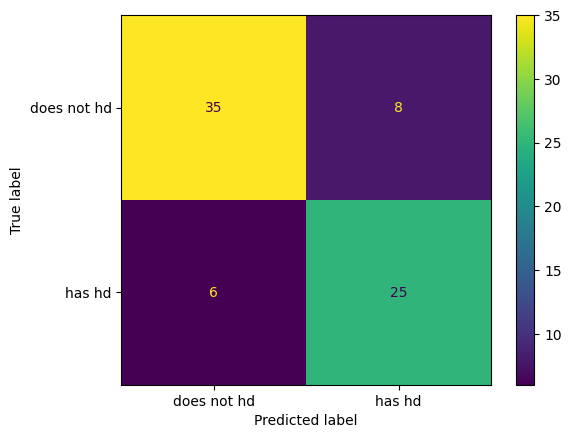

In [ ]:
clf_pruined_final = DecisionTreeClassifier(random_state=42, ccp_alpha=our_main_alpha)
clf_pruined_final = clf_pruined_final.fit(x_train,y_train)
ConfusionMatrixDisplay.from_estimator(clf_pruined_final,
                                           x_test,
                                           y_test,
                                           display_labels=["does not hd","has hd"])
                                          


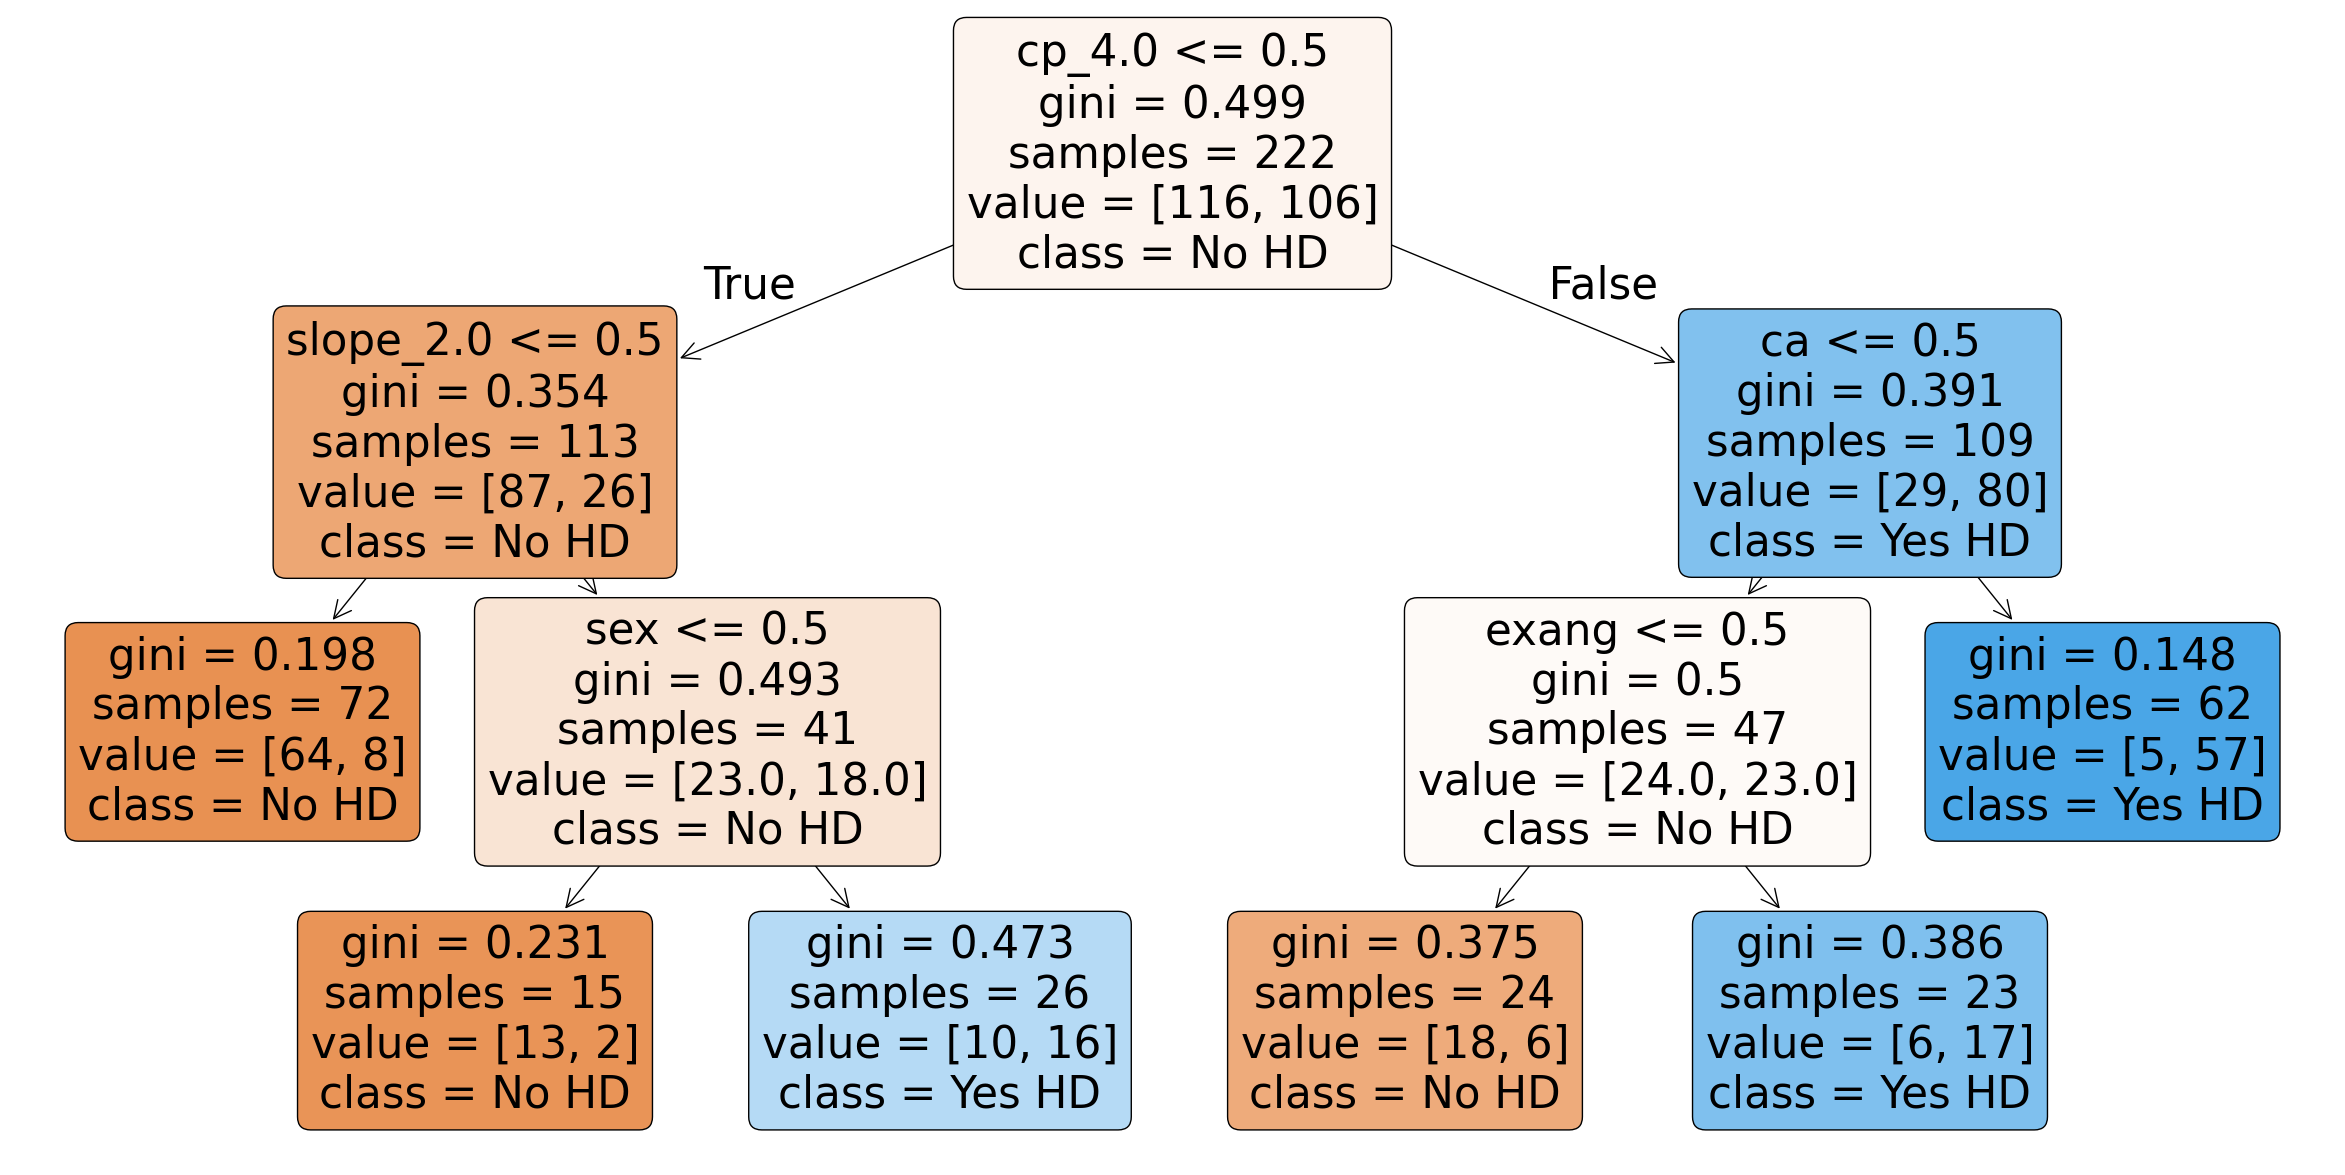

In [ ]:
plt.figure(figsize=(30, 15))
plot_tree(clf_pruined_final,
          filled=True,
          rounded=True,
          class_names=["No HD", "Yes HD"],
          feature_names=x_encoded.columns);

In [ ]:
import joblib

joblib.dump(clf_pruined_final, "models/heart_risk_dt.pkl")


['models/heart_risk_dt.pkl']

In [ ]:
model = joblib.load("models/heart_risk_dt.pkl")